
# CONVOLUTIONAL NEURAL NETWORK (CNN)

  CNN is a deep learning architecture specialized for image data:
   - Convolutional layers learn spatial features (edges, textures, patterns)
   - Pooling layers reduce dimensionality
   - Fully-connected layers for final classification
 
  Architecture:
   - Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Conv2D(64)
   - Flatten → Dense(64) → Dense(num_classes)

  Good for:
   - Image classification
   - Pattern recognition
   - Spatial feature learning
  
  Dataset: MNIST Handwritten Digits

## Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

from src.models.neural_networks import KerasCNN
from src import data_loader
from src.eda import (
    analyze_data,
    plot_feature_distributions_by_class
)
from src.preprocessing import DataPreprocessor
from src.data_utils import split_train_test

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Suppress warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("✓ Setup complete")
print(f"TensorFlow version: {tf.__version__}")

2025-12-30 23:39:41.799051: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Setup complete
TensorFlow version: 2.16.2


## Load Data & Explore


LOADING MNIST DATASET
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Image shape: (28, 28) (28x28 grayscale)
Number of classes: 10

Class distribution (training):
  Digit 0: 5923 images
  Digit 1: 6742 images
  Digit 2: 5958 images
  Digit 3: 6131 images
  Digit 4: 5842 images
  Digit 5: 5421 images
  Digit 6: 5918 images
  Digit 7: 6265 images
  Digit 8: 5851 images
  Digit 9: 5949 images


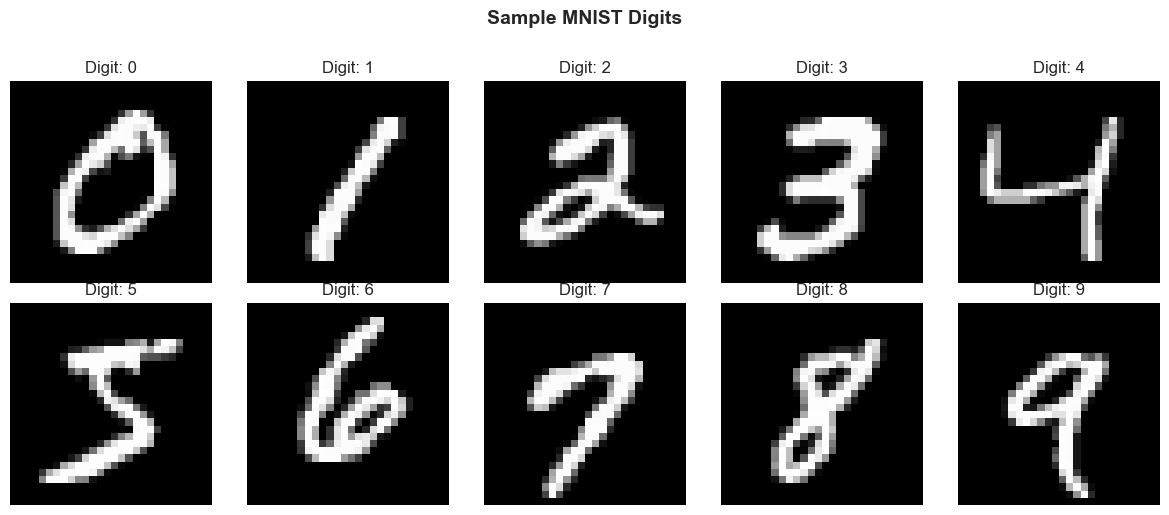

In [2]:
print("\n" + "="*70)
print("LOADING MNIST DATASET")
print("="*70)

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Image shape: {X_train.shape[1:]} (28x28 grayscale)")
print(f"Number of classes: {len(np.unique(y_train))}")

print(f"\nClass distribution (training):")
unique, counts = np.unique(y_train, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} images")

# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    # Find first occurrence of each digit
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx], cmap='gray')
    axes[i].set_title(f'Digit: {i}', fontsize=12)
    axes[i].axis('off')

plt.suptitle('Sample MNIST Digits', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Preprocess Data

In [3]:
print("\n" + "="*70)
print("PREPROCESSING")
print("="*70)

# Reshape for CNN (add channel dimension)
X_train_proc = X_train.reshape(-1, 28, 28, 1)
X_test_proc = X_test.reshape(-1, 28, 28, 1)

# Normalize pixel values to [0, 1]
X_train_proc = X_train_proc.astype('float32') / 255.0
X_test_proc = X_test_proc.astype('float32') / 255.0

print(f"Training shape: {X_train_proc.shape}")
print(f"Test shape: {X_test_proc.shape}")
print(f"Pixel value range: [{X_train_proc.min():.1f}, {X_train_proc.max():.1f}]")
print("✓ Images reshaped to (28, 28, 1)")
print("✓ Pixel values normalized to [0, 1]")

print("\n⚠️  CNN preprocessing requirements:")
print("   • 4D tensor: (samples, height, width, channels)")
print("   • Normalized pixel values (0-1 or -1 to 1)")
print("   • Consistent image dimensions")


PREPROCESSING
Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]
✓ Images reshaped to (28, 28, 1)
✓ Pixel values normalized to [0, 1]

⚠️  CNN preprocessing requirements:
   • 4D tensor: (samples, height, width, channels)
   • Normalized pixel values (0-1 or -1 to 1)
   • Consistent image dimensions


## Build CNN Model

In [4]:
print("\n" + "="*70)
print("BUILDING CNN MODEL")
print("="*70)

model = KerasCNN(
    input_shape=(28, 28, 1),
    num_classes=10
)

print("CNN Architecture:")
print("="*70)
model.summary()

print("\n💡 Layer breakdown:")
print("   • Conv2D(32): 32 filters, learns basic features (edges, lines)")
print("   • MaxPooling: Reduces spatial dimensions by 2x")
print("   • Conv2D(64): 64 filters, learns complex patterns")
print("   • Conv2D(64): 64 filters, learns high-level features")
print("   • Flatten: Converts 2D feature maps to 1D vector")
print("   • Dense(64): Fully-connected layer for classification")
print("   • Dense(10): Output layer (10 digits)")


BUILDING CNN MODEL
CNN Architecture:


/Users/cdubois/workshop/ml-fundamentals/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,554 (236.54 KB)

 Trainable params: 60,554 (236.54 KB)

 Non-trainable params: 0 (0.00 B)


💡 Layer breakdown:
   • Conv2D(32): 32 filters, learns basic features (edges, lines)
   • MaxPooling: Reduces spatial dimensions by 2x
   • Conv2D(64): 64 filters, learns complex patterns
   • Conv2D(64): 64 filters, learns high-level features
   • Flatten: Converts 2D feature maps to 1D vector
   • Dense(64): Fully-connected layer for classification
   • Dense(10): Output layer (10 digits)


## Train The Model

In [5]:
print("\n" + "="*70)
print("TRAINING CNN")
print("="*70)

print("Training parameters:")
print("  • Epochs: 10")
print("  • Batch size: 32")
print("  • Validation split: 20%")
print("  • Optimizer: Adam")
print("  • Loss: Sparse Categorical Crossentropy")

model.fit(
    X_train_proc, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\n✓ Model trained successfully")


TRAINING CNN
Training parameters:
  • Epochs: 10
  • Batch size: 32
  • Validation split: 20%
  • Optimizer: Adam
  • Loss: Sparse Categorical Crossentropy
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.9241 - loss: 0.2468 - val_accuracy: 0.9712 - val_loss: 0.0930
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9747 - loss: 0.0831 - val_accuracy: 0.9784 - val_loss: 0.0710
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9823 - loss: 0.0587 - val_accuracy: 0.9803 - val_loss: 0.0710
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9861 - loss: 0.0451 - val_accuracy: 0.9727 - val_loss: 0.0943
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.9895 - loss: 0.0351 - val_accuracy: 0.9818 - val_loss: 0.0700
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9908 - loss: 0.0290 - val_accuracy: 0.9789 - val_loss: 0.0801
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/

## Train History Visualization

In [ ]:
print("\n" + "="*70)
print("TRAINING HISTORY")
print("="*70)

# Access training history
history = model.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze training
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc

print(f"\nFinal training accuracy: {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")
print(f"Train-validation gap: {gap:.4f}")

if gap > 0.05:
    print("\n⚠️  Moderate overfitting detected")
    print("   Consider: dropout, data augmentation, early stopping")
elif gap > 0.10:
    print("\n⚠️  Significant overfitting!")
    print("   Action needed: regularization, more data")
else:
    print("\n✓ Good generalization - minimal overfitting")

## Model Evaluation

In [ ]:
print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# Predictions
y_pred = model.predict(X_test_proc)
test_accuracy = model.score(X_test_proc, y_test)

print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.ylabel('Actual Digit', fontsize=12)
plt.xlabel('Predicted Digit', fontsize=12)
plt.title('Confusion Matrix - MNIST CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Per-class accuracy
print("\nPer-digit accuracy:")
for digit in range(10):
    mask = y_test == digit
    digit_acc = (y_pred[mask] == digit).mean()
    print(f"  Digit {digit}: {digit_acc:.4f}")